### Implementing a Neural Network From Scratch

in this Repository i will implement a 4-layer neural network form scratch.

In [2]:
# package imports

import matplotlib.pyplot as plt
import numpy as np
import sklearn
import sklearn.datasets
import sklearn.linear_model
import matplotlib

# Display plots inline and change default figure size
%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (10.0, 8.0)

### Generating a dataset

let's generate a dataset from **scikit-learn**.
We will go with the *make_moons* function.

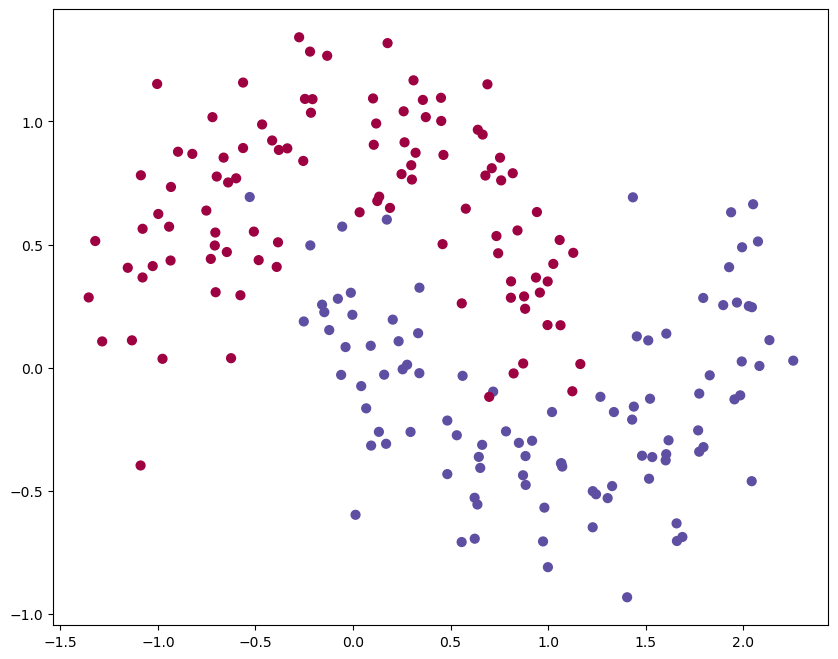

In [3]:
# Generate dataset and plot it
np.random.seed(0)
X, y = sklearn.datasets.make_moons(200, noise=0.20)
plt.scatter(X[:, 0], X[: ,1], s=40, c=y, cmap=plt.cm.Spectral)

the dataset we generated has **two classes**, plotted as red and blue points. We can think of blue dots as a male patients and the red dots as a female patients, with the x- and y- axis being medical measurements.

### Logistic Regression

let's try to train **Logistic Regression Classifier**. It's input will be the x- and y-values and the output the predicted class (0 or 1).

In [4]:
clf = sklearn.linear_model.LogisticRegressionCV()
clf.fit(X, y)

,Cs,10
,fit_intercept,True
,cv,None
,dual,False
,penalty,'l2'
,scoring,None
,solver,'lbfgs'
,tol,0.0001
,max_iter,100
,class_weight,None
,n_jobs,None


In [5]:
# Helper function  to plot a decision boundary.

def plot_decision_boundary(pred_func):
    # Set min and max values and give it some padding
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    h = 0.01
    # Generate a grid of points with distances h between them
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    # Predict the function value for the whole grid
    Z = pred_func(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    # Plot the contour and the training examples
    plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Spectral)

Text(0.5, 1.0, 'Logistic Regression')

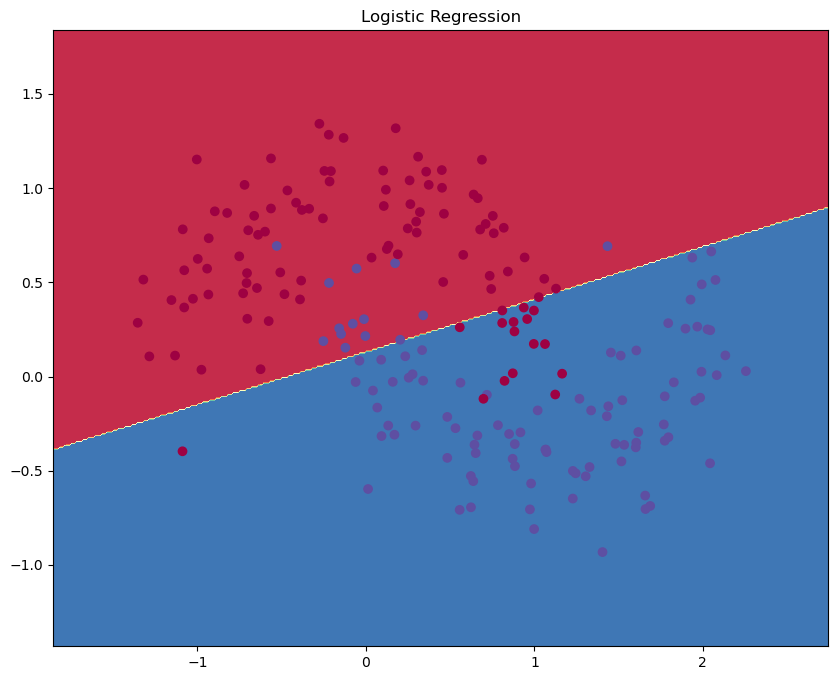

In [6]:
#Plot the decision boundary
plot_decision_boundary(lambda x: clf.predict(x))
plt.title("Logistic Regression")

the graph shows the decision boundary learned by our **Logistic Regression Classifier**. Using a straight line to make a classifiction, but it's unable to capture the "moon shape" of our data

### Training a Neural Network

Let's now build a 4-layer neural network with one input layer, two hidden layer, and one output layer.
the number of nodes in the output layer is determined by the number of classes we have, also 2.
(We could actually get away with only one output node predicting 0 or 1, but having 2 makes it easier to extend the network to more classes later on). The input to the network will be x- and y- coordinates and it's output will be **two Probabilities** one for class 0 ("female") and the another will be for class 1 ("male").

it looks like this:
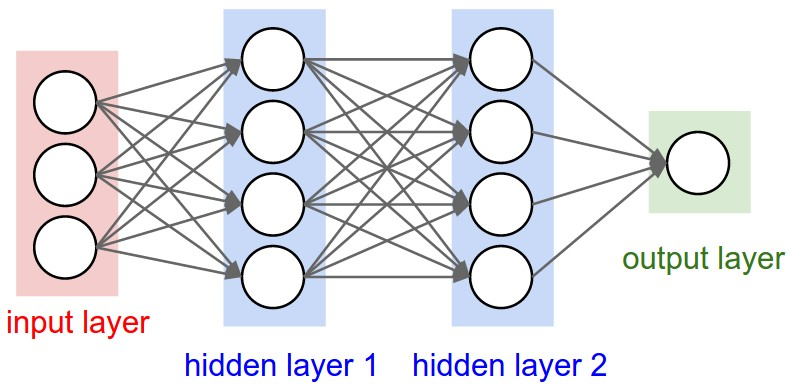
**ignore the third node of the input layer**

We can choose the dimensionality (number of nodes in the hidden layer). The more nodes we put into the hidden layer the more complex functions we will be able to fit.
But it comes at a cost. First, more computation is required to make predictions and learn the network parameters. A bigger number of parameters also means we become more **prone to overfitting our data**

We also need to pick an *activation function* for our hidden layers. We will use **tanh**, which preforms quite well.

Because we want our network to output probabilities the activation function for the output layer will be the **softmax**

### How our network makes predictions

Our network makes predictions using *forward propagation*.
If $x$ is the 2-dimensional input for our network then we calculate our predicition $\hat{y}$ (also two-dimensional) as follows:
$$
\begin{aligned}
z_1 &= xW_1 + b_1 \\
a_1 &= \tanh(z_1) \\
z_2 &= a_1W_2 + b_2 \\
a_2 &= \tanh(z_2) \\
z_3 &= a_2W_3 + b_3 \\
a_3 &= \hat{y} = \text{softmax}(z_3)
\end{aligned}
$$

$z_i$ is the weighted sum of inputs of layer $i$ (bias included) and $a_i$ is the output of layer $i$ after applying the activation function. $W_1$, $b_1$, $W_2$, $b_2$
are parameters of out network, which we need to **learn from our training data**.

### Learning the parameters

Learning the parameters for our network means finding parameters ($W_1$, $b_1$, $W_2$, $b_2$) that minimize the error on our training data. We call the function that measures out error the **loss function**. A common choice with the softmax output is the **cross-entropy loss**. If we have $N$ training examples and $C$ classes then the loss for our prediction $\hat{y}$ with respect to the true labels $y$ is given by: 
$$
L(y, \hat{y}) = -\frac{1}{N} \sum_{n \in N} \sum_{i \in C} y_{n,i} \log \hat{y}_{n,i}
$$

Our goal is to find the parameters that minimize our **loss function**. We can use *gradient descent* to find it's minimum. For this implementation i will use **batch gradient descent**.

As an input, gradient descent needs the gradients (vector of derivatives) of the loss function with respect to our parameters: $\frac{\partial L}{\partial W_1}, \frac{\partial L}{\partial b_1}, \frac{\partial L}{\partial W_2}, \frac{\partial L}{\partial b_2}, \frac{\partial L}{\partial W_3}, \frac{\partial L}{\partial b_3}$. To calculate these gradeints we use the famous **backpropagation algorithm**, which is efficiently calculate the gradients starting from the output. 

Applying the backpropagation formula we find the following:

$$
\begin{aligned}
\delta_4 &= \hat{y} - y \\
\delta_3 &= (1 - \tanh^2 z_2) \circ \delta_4 W_3^T \\
\delta_2 &= (1 - \tanh^2 z_1) \circ \delta_3 W_2^T \\
\frac{\partial L}{\partial W_3} &= a_2^T \delta_4 \\
\frac{\partial L}{\partial b_3} &= \delta_4 \\
\frac{\partial L}{\partial W_2} &= a_1^T \delta_3 \\
\frac{\partial L}{\partial b_2} &= \delta_3 \\
\frac{\partial L}{\partial W_1} &= x^T \delta_2 \\
\frac{\partial L}{\partial b_1} &= \delta_2
\end{aligned}
$$

### Implementation

In [35]:
num_examples = len(X)
nn_input_dim = 2
nn_output_dim = 2

# Gradient descent parameters
epsilon = 0.01
reg_lambda = 0.01

In [30]:
# Helper function to evaluate the total loss on the dataset

def calculate_loss(model):
    W1, b1, W2, b2, W3, b3 = model['W1'], model['b1'], model['W2'], model['b2'], model['W3'], model['b3']
    # Forward propagation to calculate our predictions
    z1 = X.dot(W1) + b1
    a1 = np.tanh(z1)
    z2 = a1.dot(W2) + b2
    a2 = np.tanh(z2)
    z3 = a2.dot(W3) + b3
    exp_scores = np.exp(z3)
    probs = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)
    # Calculating the loss
    correct_logprobs = -np.log(probs[range(num_examples), y])
    data_loss = np.sum(correct_logprobs)
    # Add regularization term to loss
    data_loss += reg_lambda/2 * (np.sum(np.square(W1)) + np.sum(np.square(W2)) + np.sum(np.square(W3)))
    return 1./num_examples * data_loss

In [31]:
# Helper function to predict an output (0 or 1)
def predict(model, x):
    W1, b1, W2, b2, W3, b3 = model['W1'], model['b1'], model['W2'], model['b2'], model['W3'], model['b3']
    # Forward propagation
    z1 = x.dot(W1) + b1
    a1 = np.tanh(z1)
    z2 = a1.dot(W2) + b2
    a2 = np.tanh(z2)
    z3 = a2.dot(W3) + b3
    exp_scores = np.exp(z3)
    probs = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)
    return np.argmax(probs, axis=1)

Finally, here comes the function to train our Neural Network. It implements batch gradient descent using the backpropagation derivates we found above.

In [36]:
# This function learns parameters for the neural network and returns the model
# - nn_hdim: Number of nodes in the hidden layer
# - num_passes: Number of passes through the training data for gradient descent
# - print_loss: If true, print loss every 1000 iterations

def build_model(nn_hdim, num_passes=20000, print_loss=False):
    # Initialize the parameters to random values. We need to learn these.
    np.random.seed(0)
    W1 = np.random.randn(nn_input_dim, nn_hdim) / np.sqrt(nn_input_dim)
    b1 = np.zeros((1, nn_hdim))
    W2 = np.random.randn(nn_hdim, nn_hdim) / np.sqrt(nn_hdim)
    b2 = np.zeros((1, nn_hdim))
    W3 = np.random.randn(nn_hdim, nn_output_dim) / np.sqrt(nn_hdim)
    b3 = np.zeros((1, nn_output_dim))

    # This is what we return at the end
    model = {}

    # Gradient descent. For each batch...
    for i in range(0, num_passes):
        # Forward propagation
        z1 = X.dot(W1) + b1
        a1 = np.tanh(z1)
        z2 = a1.dot(W2) + b2
        a2 = np.tanh(z2)
        z3 = a2.dot(W3) + b3
        exp_scores = np.exp(z3)
        probs = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)

        # Backpropagation
        delta4 = probs
        delta4[range(num_examples), y] -= 1
        dW3 = (a2.T).dot(delta4)
        db3 = np.sum(delta4, axis=0, keepdims=True)
        delta3 = delta4.dot(W3.T) * (1 - np.power(a2, 2))
        dW2 = (a1.T).dot(delta3)
        db2 = np.sum(delta3, axis=0, keepdims=True)
        delta2 = delta3.dot(W2.T) * (1 - np.power(a1, 2))
        dW1 = (X.T).dot(delta2)
        db1 = np.sum(delta2, axis=0)

        # Add regularization terms (b1, b2, and b3 do not have regularization term)
        dW3 += reg_lambda * W3
        dW2 += reg_lambda * W2
        dW1 += reg_lambda * W1

        # Gradient descent parameter update
        W1 += -epsilon * dW1
        b1 += -epsilon * db1
        W2 += -epsilon * dW2
        b2 += -epsilon * db2
        W3 += -epsilon * dW3
        b3 += -epsilon * db3

        # Assign new parameters to the model
        model = {'W1': W1, 'b1': b1,
                 'W2': W2, 'b2': b2,
                 'W3': W3, 'b3': b3}

        # print the loss.
        if print_loss and i % 1000 == 0:
            print("Loss after iteration %i: %f" %(i, calculate_loss(model)))

    return model

### A network with a hidden layer of size 4

Let's see what happens if we train a network with a hidden layer of size 4

Loss after iteration 0: 0.490661
Loss after iteration 1000: 0.063983
Loss after iteration 2000: 0.057018
Loss after iteration 3000: 0.039026
Loss after iteration 4000: 0.042356
Loss after iteration 5000: 0.036496
Loss after iteration 6000: 0.283020
Loss after iteration 7000: 0.040652
Loss after iteration 8000: 0.014298
Loss after iteration 9000: 0.038847
Loss after iteration 10000: 0.012763
Loss after iteration 11000: 0.033267
Loss after iteration 12000: 0.032627
Loss after iteration 13000: 0.032900
Loss after iteration 14000: 0.030139
Loss after iteration 15000: 0.030755
Loss after iteration 16000: 0.030127
Loss after iteration 17000: 0.029046
Loss after iteration 18000: 0.076906
Loss after iteration 19000: 0.167062


Text(0.5, 1.0, 'Decision Boundary for hidden layer of size 4')

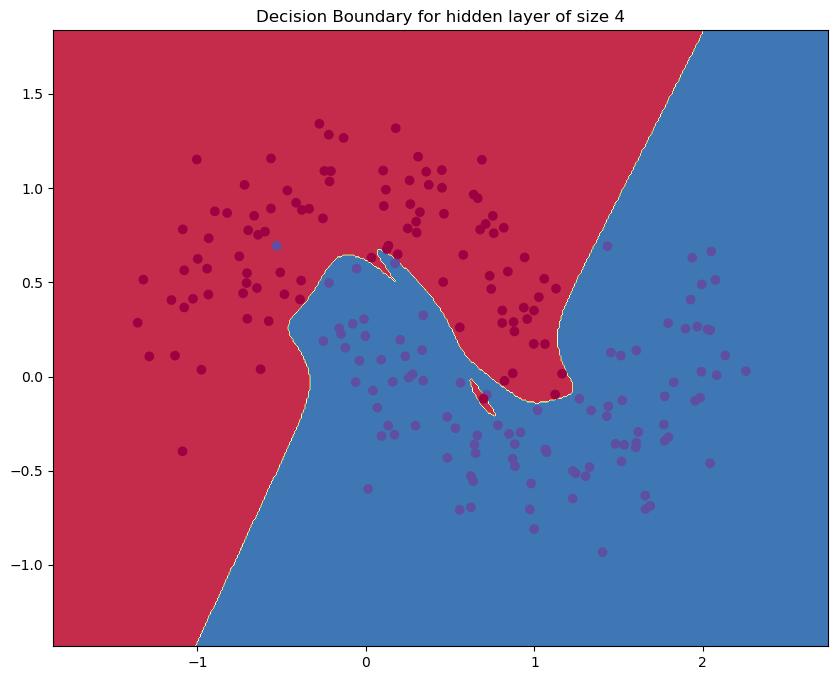

In [37]:
# build a model with a 4-dimensional hidden layer
model = build_model(4, print_loss=True)

#plot the decision boundary
plot_decision_boundary(lambda x: predict(model, x))
plt.title("Decision Boundary for hidden layer of size 4")

### Varying the hidden layer size

Let's now get a sense of how varying the hidden layer size affects the result


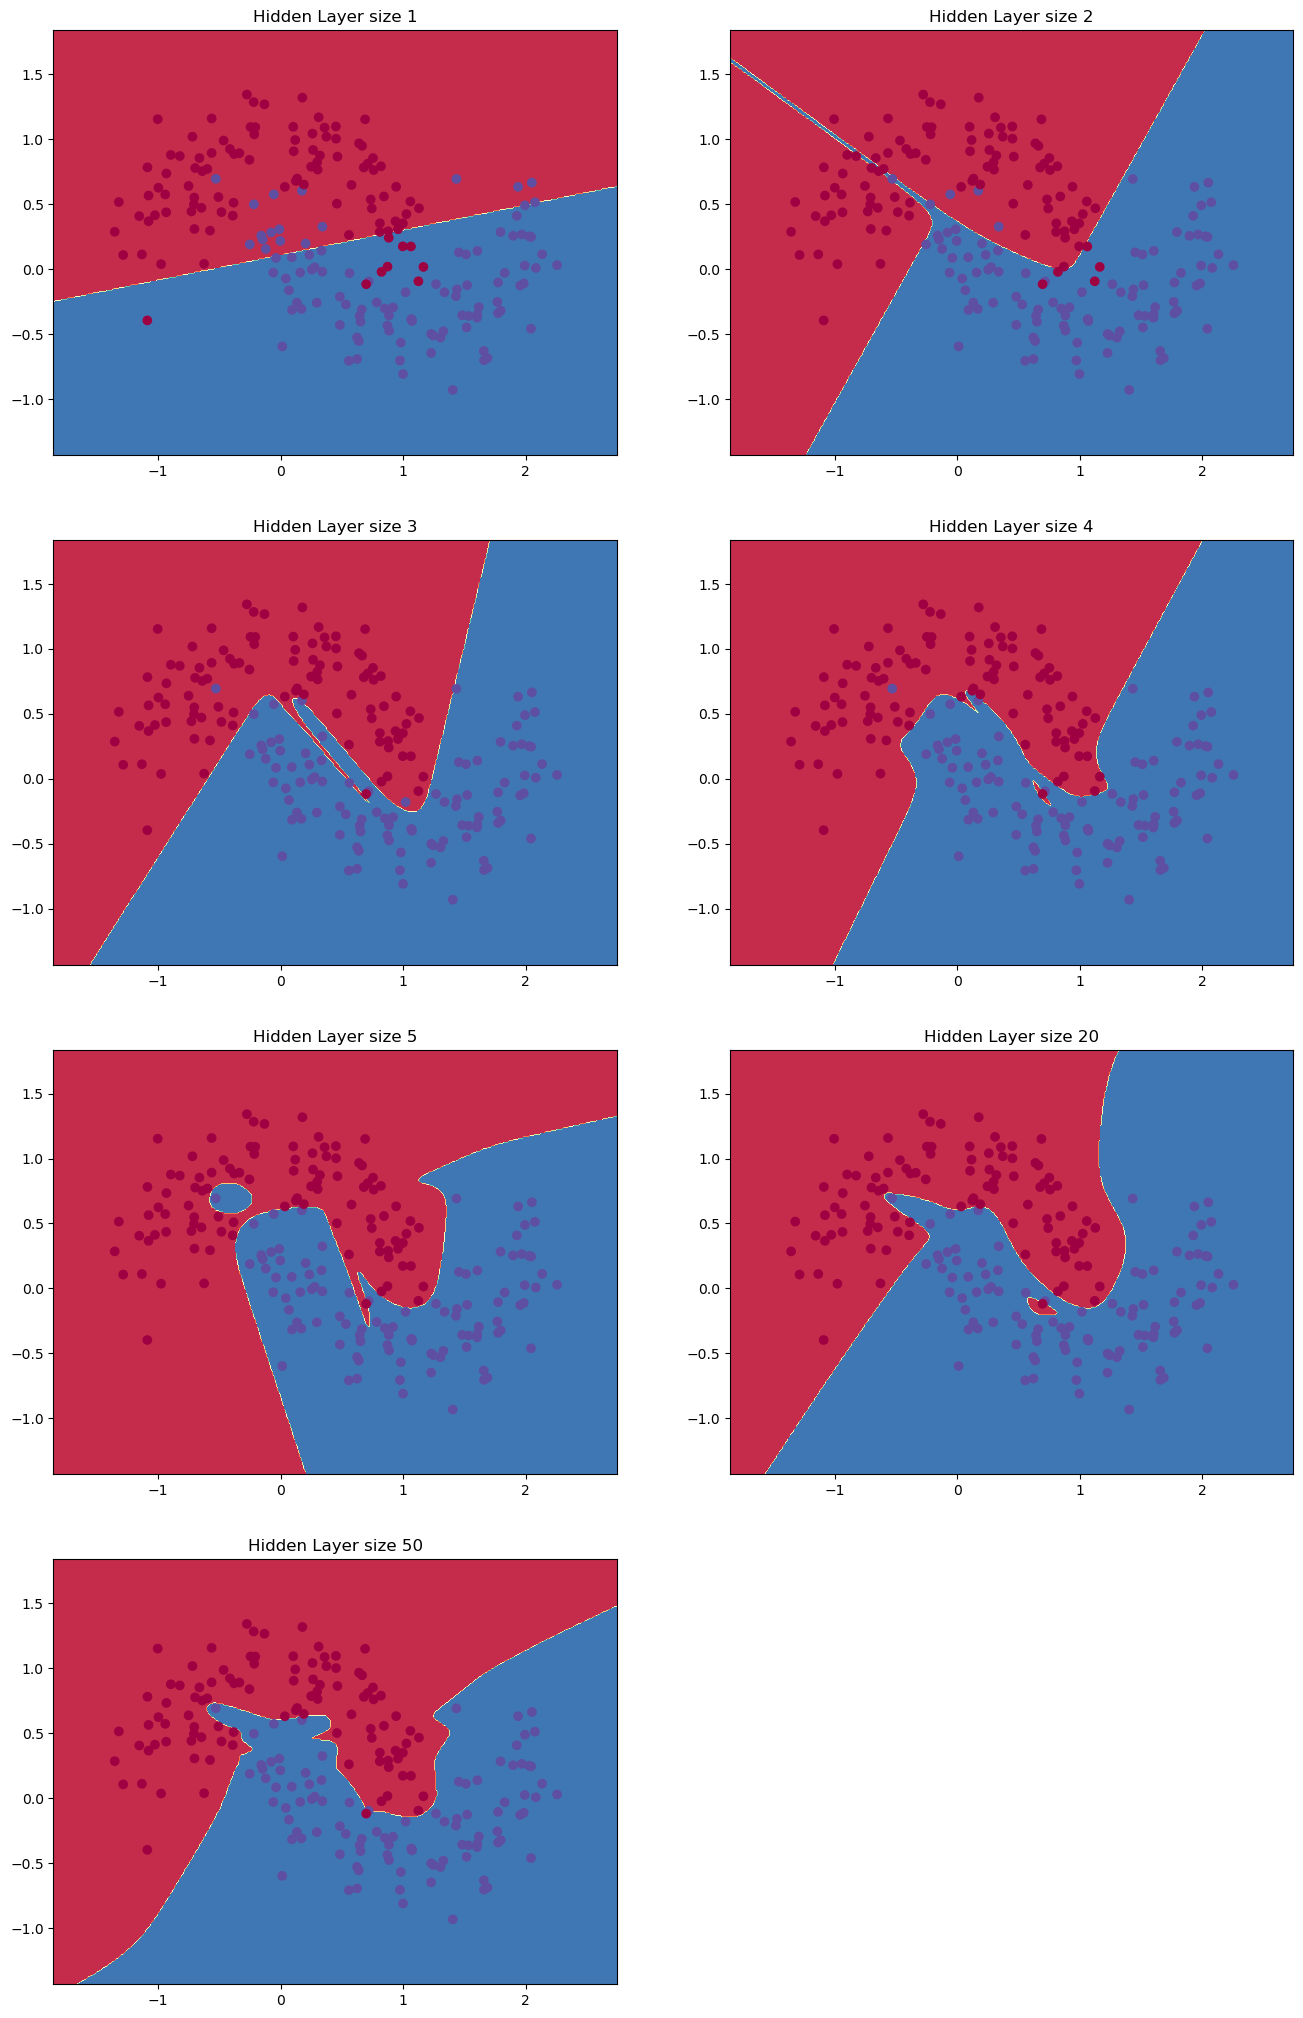

In [38]:
plt.figure(figsize=(16, 32))
hidden_layer_dimensions = [1, 2, 3, 4, 5, 20, 50]

for i, nn_hdim in enumerate(hidden_layer_dimensions):
    plt.subplot(5, 2, i+1)
    plt.title('Hidden Layer size %d' % nn_hdim)
    model = build_model(nn_hdim)
    plot_decision_boundary(lambda x: predict(model, x))
plt.show()


We can see that while a hidden layer of low dimensionality nicely capture the general trend of our data, but higher dimensionalities are prone to **overfitting**. They are "memorizing" the data as opposed to fitting the general shape. If we were to evaluate our model on a separate test set the model with a **smaller hidden layer size** would likely perform better because it generalizes better.